In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

In [3]:
df = pd.read_csv("Crime_Data_from_2020_to_Present.csv")

In [4]:
df.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,211507896,04/11/2021 12:00:00 AM,11/07/2020 12:00:00 AM,845,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,NaN,NaN,NaN,7800 BEEMAN AV,NaN,34.2124,-118.4092
1,201516622,10/21/2020 12:00:00 AM,10/18/2020 12:00:00 AM,1845,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,IC,Invest Cont,230.0,NaN,NaN,NaN,ATOLL AV,N GAULT,34.1993,-118.4203
2,240913563,12/10/2024 12:00:00 AM,10/30/2020 12:00:00 AM,1240,9,Van Nuys,933,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,NaN,NaN,NaN,14600 SYLVAN ST,NaN,34.1847,-118.4509
3,210704711,12/24/2020 12:00:00 AM,12/24/2020 12:00:00 AM,1310,7,Wilshire,782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,...,IC,Invest Cont,331.0,NaN,NaN,NaN,6000 COMEY AV,NaN,34.0339,-118.3747
4,201418201,10/03/2020 12:00:00 AM,09/29/2020 12:00:00 AM,1830,14,Pacific,1454,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),...,IC,Invest Cont,420.0,NaN,NaN,NaN,4700 LA VILLA MARINA,NaN,33.9813,-118.4350


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004991 entries, 0 to 1004990
Data columns (total 28 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   DR_NO           1004991 non-null  int64  
 1   Date Rptd       1004991 non-null  object 
 2   DATE OCC        1004991 non-null  object 
 3   TIME OCC        1004991 non-null  int64  
 4   AREA            1004991 non-null  int64  
 5   AREA NAME       1004991 non-null  object 
 6   Rpt Dist No     1004991 non-null  int64  
 7   Part 1-2        1004991 non-null  int64  
 8   Crm Cd          1004991 non-null  int64  
 9   Crm Cd Desc     1004991 non-null  object 
 10  Mocodes         853372 non-null   object 
 11  Vict Age        1004991 non-null  int64  
 12  Vict Sex        860347 non-null   object 
 13  Vict Descent    860335 non-null   object 
 14  Premis Cd       1004975 non-null  float64
 15  Premis Desc     1004403 non-null  object 
 16  Weapon Used Cd  327247 non-null   fl

In [6]:
df.isnull().sum()

DR_NO                   0
Date Rptd               0
DATE OCC                0
TIME OCC                0
AREA                    0
AREA NAME               0
Rpt Dist No             0
Part 1-2                0
Crm Cd                  0
Crm Cd Desc             0
Mocodes            151619
Vict Age                0
Vict Sex           144644
Vict Descent       144656
Premis Cd              16
Premis Desc           588
Weapon Used Cd     677744
Weapon Desc        677744
Status                  1
Status Desc             0
Crm Cd 1               11
Crm Cd 2           935831
Crm Cd 3          1002677
Crm Cd 4          1004927
LOCATION                0
Cross Street       850755
LAT                     0
LON                     0
dtype: int64

In [7]:
df.isnull().mean()*100

DR_NO              0.000000
Date Rptd          0.000000
DATE OCC           0.000000
TIME OCC           0.000000
AREA               0.000000
AREA NAME          0.000000
Rpt Dist No        0.000000
Part 1-2           0.000000
Crm Cd             0.000000
Crm Cd Desc        0.000000
Mocodes           15.086603
Vict Age           0.000000
Vict Sex          14.392567
Vict Descent      14.393761
Premis Cd          0.001592
Premis Desc        0.058508
Weapon Used Cd    67.437818
Weapon Desc       67.437818
Status             0.000100
Status Desc        0.000000
Crm Cd 1           0.001095
Crm Cd 2          93.118346
Crm Cd 3          99.769749
Crm Cd 4          99.993632
LOCATION           0.000000
Cross Street      84.652997
LAT                0.000000
LON                0.000000
dtype: float64

In [8]:
df['Weapon Desc'].value_counts()

Weapon Desc
STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)    174761
UNKNOWN WEAPON/OTHER WEAPON                        36390
VERBAL THREAT                                      23846
HAND GUN                                           20182
SEMI-AUTOMATIC PISTOL                               7267
                                                   ...  
MAC-11 SEMIAUTOMATIC ASSAULT WEAPON                    3
HECKLER & KOCH 91 SEMIAUTOMATIC ASSAULT RIFLE          2
MAC-10 SEMIAUTOMATIC ASSAULT WEAPON                    2
M-14 SEMIAUTOMATIC ASSAULT RIFLE                       2
M1-1 SEMIAUTOMATIC ASSAULT RIFLE                       1
Name: count, Length: 79, dtype: int64

In [9]:
null_weapon_df = df[df['Weapon Desc'].isna()]
top_null_weapon_crimes = null_weapon_df['Crm Cd Desc'].value_counts()
top_null_weapon_crimes.head(25)

Crm Cd Desc
VEHICLE - STOLEN                                            115136
THEFT OF IDENTITY                                            62514
BURGLARY FROM VEHICLE                                        60125
VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)      55043
THEFT PLAIN - PETTY ($950 & UNDER)                           51964
BURGLARY                                                     50248
THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER)              41035
THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND OVER)          36551
THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LIVESTK,PROD     33676
SHOPLIFTING - PETTY THEFT ($950 & UNDER)                     30547
VANDALISM - MISDEAMEANOR ($399 OR UNDER)                     22784
TRESPASSING                                                  17907
VIOLATION OF RESTRAINING ORDER                               11131
LETTERS, LEWD  -  TELEPHONE CALLS, LEWD                       8183
BIKE - STOLEN                                     

This indicates that the empty values ​​in the "Weapon Desc" column are No Weapons.

In [10]:
df['Weapon Desc'].fillna('NONE', inplace=True)

C:\Users\muhan\AppData\Local\Temp\ipykernel_11016\879229549.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Weapon Desc'].fillna('NONE', inplace=True)


In [11]:
df.dropna(subset=['Premis Desc'], inplace=True)

We got rid of all the null values

In [12]:
df.isnull().sum()

DR_NO                   0
Date Rptd               0
DATE OCC                0
TIME OCC                0
AREA                    0
AREA NAME               0
Rpt Dist No             0
Part 1-2                0
Crm Cd                  0
Crm Cd Desc             0
Mocodes            151601
Vict Age                0
Vict Sex           144628
Vict Descent       144640
Premis Cd               0
Premis Desc             0
Weapon Used Cd     677359
Weapon Desc             0
Status                  0
Status Desc             0
Crm Cd 1               11
Crm Cd 2           935390
Crm Cd 3          1002089
Crm Cd 4          1004339
LOCATION                0
Cross Street       850187
LAT                     0
LON                     0
dtype: int64

Drop 19 columns

In [13]:
df = df.drop(columns=['DR_NO', 'Date Rptd', 'AREA', 'Rpt Dist No', 'Vict Age', 'Vict Sex', 'Vict Descent', 'Crm Cd 1', 'Crm Cd 2',
                      'Crm Cd 3', 'Crm Cd 4', 'Cross Street', 'LOCATION', 'Mocodes', 'Weapon Used Cd', 'Premis Cd',
                      'Status', 'Status Desc', 'Crm Cd'])

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1004403 entries, 0 to 1004990
Data columns (total 9 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   DATE OCC     1004403 non-null  object 
 1   TIME OCC     1004403 non-null  int64  
 2   AREA NAME    1004403 non-null  object 
 3   Part 1-2     1004403 non-null  int64  
 4   Crm Cd Desc  1004403 non-null  object 
 5   Premis Desc  1004403 non-null  object 
 6   Weapon Desc  1004403 non-null  object 
 7   LAT          1004403 non-null  float64
 8   LON          1004403 non-null  float64
dtypes: float64(2), int64(2), object(5)
memory usage: 76.6+ MB


In [15]:
df.duplicated().sum()

np.int64(22385)

In [16]:
df.drop_duplicates(inplace=True)

In [17]:
df['Hour'] = df['TIME OCC'].astype(str).str.zfill(4).str[:2].astype(int)

def classify_time_period(hour):
    if 6 <= hour <= 17:
        return 0
    else:
        return 1

df['Is_Night_Time'] = df['Hour'].apply(classify_time_period)
df['TIME OCC']=df['TIME OCC'].astype(int)

df['Hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
df['Hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)

df.drop(columns=['TIME OCC'], inplace=True)

In [18]:
df['Is_Night_Time'].value_counts()

Is_Night_Time
0    525999
1    456019
Name: count, dtype: int64

In [19]:
df['Weapon Desc'].value_counts()

Weapon Desc
NONE                                              672138
STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)    166772
UNKNOWN WEAPON/OTHER WEAPON                        35363
VERBAL THREAT                                      22496
HAND GUN                                           18278
                                                   ...  
HECKLER & KOCH 91 SEMIAUTOMATIC ASSAULT RIFLE          2
M-14 SEMIAUTOMATIC ASSAULT RIFLE                       2
MAC-10 SEMIAUTOMATIC ASSAULT WEAPON                    2
MAC-11 SEMIAUTOMATIC ASSAULT WEAPON                    1
M1-1 SEMIAUTOMATIC ASSAULT RIFLE                       1
Name: count, Length: 80, dtype: int64

In [20]:
df['Crm Cd Desc'].value_counts()

Crm Cd Desc
VEHICLE - STOLEN                                           114099
BATTERY - SIMPLE ASSAULT                                    68844
BURGLARY FROM VEHICLE                                       63319
THEFT OF IDENTITY                                           62244
VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)     60825
                                                            ...  
FIREARMS RESTRAINING ORDER (FIREARMS RO)                        4
FAILURE TO DISPERSE                                             4
DISHONEST EMPLOYEE ATTEMPTED THEFT                              4
TRAIN WRECKING                                                  1
DRUNK ROLL - ATTEMPT                                            1
Name: count, Length: 140, dtype: int64

In [21]:
df['Premis Desc'].value_counts()

Premis Desc
STREET                                          255345
SINGLE FAMILY DWELLING                          160022
MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)    116147
PARKING LOT                                      67593
OTHER BUSINESS                                   46814
                                                 ...  
MTA - SILVER LINE - LAC/USC MEDICAL CENTER           2
DEPT OF DEFENSE FACILITY                             2
MTA - SILVER LINE - DOWNTOWN STREET STOPS            2
HORSE RACING/SANTA ANITA PARK*                       2
TRAM/STREETCAR(BOXLIKE WAG ON RAILS)*                1
Name: count, Length: 306, dtype: int64

In [22]:
def categorize_weapon(description):

    desc = str(description).upper()

    if any(keyword in desc for keyword in ['GUN', 'PISTOL', 'REVOLVER', 'RIFLE', 'FIREARM', 'SHOTGUN', 'UZI', 'AK47', 'ASSAULT', 'HECKLER']):
        return 'Firearm'
    
    elif any(keyword in desc for keyword in ['KNIFE', 'BLADE', 'DAGGER', 'MACHETE', 'AXE', 'SWORD', 'SCISSORS', 'CLEAVER', 'ICE PICK', 'SCREWDRIVER', 'GLASS', 'BOTTLE', 'SYRINGE', 'RAZOR']):
        return 'Sharp Weapon'
    
    elif any(keyword in desc for keyword in ['STRONG-ARM', 'HANDS', 'FIST', 'FEET', 'PHYSICAL PRESENCE']):
        return 'Physical Force'

    elif any(keyword in desc for keyword in ['NONE', 'VERBAL', 'DEMAND NOTE']):
        return 'none'

    else:
        return 'Other'

df['Weapon Desc'] = df['Weapon Desc'].apply(categorize_weapon)

df['Weapon Desc'].head()

0            none
1    Sharp Weapon
2            none
3            none
4            none
Name: Weapon Desc, dtype: object

In [23]:
def categorize_crime_refined(description):
    desc = str(description).upper()

    if any(keyword in desc for keyword in ['RAPE', 'SEX', 'LEWD', 'SODOMY', 'ORAL COPULATION', 'PIMPING', 'PANDERING', 'INCEST', 'BEASTIALITY', 'HUMAN TRAFFICKING', 'PORNOGRAPHY', 'PEEPING']):
        return 'Sexual Crimes'

    elif any(keyword in desc for keyword in ['IDENTITY', 'FORGERY', 'FRAUD', 'COUNTERFEIT', 'BUNCO', 'CREDIT CARDS', 'DOCUMENT', 'EMBEZZLEMENT', 'DISHONEST', 'BRIBERY', 'FALSE POLICE', 'BAD CHECKS']):
        return 'Fraud & White Collar'
    
    elif any(keyword in desc for keyword in ['ASSAULT', 'BATTERY', 'ROBBERY', 'HOMICIDE', 'MANSLAUGHTER', 'KIDNAPPING', 'SHOTS', 'BRANDISH', 'WEAPON', 'LYNCHING', 'EXTORTION', 'STALKING', 'THREAT', 'ABUSE', 'CRUELTY', 'THROWING OBJECT']):
        return 'Violent Crimes'

    elif any(keyword in desc for keyword in ['VANDALISM', 'ARSON', 'DAMAGE', 'TRAIN WRECKING']):
        return 'Vandalism & Damage'

    elif any(keyword in desc for keyword in ['THEFT', 'BURGLARY', 'STOLEN', 'SHOPLIFTING', 'VEHICLE', 'BIKE', 'BOAT', 'PICKPOCKET', 'PURSE', 'TILL TAP', 'DRUNK ROLL', 'SCOOTERS', 'GRAND']):
        return 'Theft & Burglary'

    else:
        return 'Public Order & Other'

df['Crm Cd Desc'] = df['Crm Cd Desc'].apply(categorize_crime_refined)

df['Crm Cd Desc'].head(10)

0    Fraud & White Collar
1          Violent Crimes
2    Fraud & White Collar
3        Theft & Burglary
4        Theft & Burglary
5    Fraud & White Collar
6    Fraud & White Collar
7    Public Order & Other
8    Fraud & White Collar
9    Fraud & White Collar
Name: Crm Cd Desc, dtype: object

In [24]:
def categorize_premise(description):
    desc = str(description).upper()

    if any(keyword in desc for keyword in ['STREET', 'SIDEWALK', 'ALLEY', 'PARK', 'BEACH', 'VACANT LOT', 'RIVER', 'UNDERPASS', 'TUNNEL', 'BRIDGE', 'TRANSIENT ENCAMPMENT', 'PUBLIC RESTROOM']):
        return 'Street & Public Space'

    elif any(keyword in desc for keyword in ['PARKING', 'VEHICLE', 'MTA', 'BUS', 'TRAIN', 'AIRPORT', 'TERMINAL', 'STATION', 'METROLINK', 'AMTRAK', 'DRIVEWAY', 'GARAGE', 'FREEWAY', 'TAXI', 'AIRCRAFT', 'BOAT', 'DOCK']):
        return 'Transportation & Parking'

    elif any(keyword in desc for keyword in ['DWELLING', 'APARTMENT', 'RESIDENCE', 'HOUSE', 'CONDO', 'HOTEL', 'MOTEL', 'PORCH', 'YARD', 'GROUP HOME', 'FOSTER', 'SHELTER', 'NURSING', 'HOME', 'PROJECT/TENEMENT']):
        return 'Residential'

    elif any(keyword in desc for keyword in ['SCHOOL', 'COLLEGE', 'UNIVERSITY', 'HOSPITAL', 'CHURCH', 'TEMPLE', 'MOSQUE', 'SYNAGOGUE', 'POLICE', 'JAIL', 'GOVERNMENT', 'LIBRARY', 'MEDICAL', 'FIRE STATION', 'MISSION', 'CEMETARY']):
        return 'Institutional & Community'

    elif any(keyword in desc for keyword in ['STORE', 'MARKET', 'RESTAURANT', 'BUSINESS', 'OFFICE', 'BANK', 'BAR', 'CLUB', 'MALL', 'SHOP', 'GAS STATION', 'LAUNDROMAT', 'GYM', 'SPA', 'THEATRE', 'CAFE', 'LIQUOR', 'SWAP MEET', 'CONSTRUCTION SITE', 'FACTORY', 'WAREHOUSE']):
        return 'Commercial & Business'

    else:
        return 'Other'

df['Premis Desc'] = df['Premis Desc'].apply(categorize_premise)

df['Premis Desc'].value_counts()

Premis Desc
Street & Public Space        388733
Residential                  308922
Transportation & Parking     144134
Commercial & Business         85478
Other                         35518
Institutional & Community     19233
Name: count, dtype: int64

In [25]:
df['Date'] = pd.to_datetime(df['DATE OCC'])
df['DATE OCC'] = pd.to_datetime(df['DATE OCC'])

C:\Users\muhan\AppData\Local\Temp\ipykernel_11016\413295115.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['DATE OCC'])
C:\Users\muhan\AppData\Local\Temp\ipykernel_11016\413295115.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DATE OCC'] = pd.to_datetime(df['DATE OCC'])


In [26]:
df['DayOfWeek'] = df['DATE OCC'].dt.dayofweek

cycle_length_day = 7

df['DayOfWeek_sin'] = np.sin(2 * np.pi * df['DayOfWeek'] / cycle_length_day)
df['DayOfWeek_cos'] = np.cos(2 * np.pi * df['DayOfWeek'] / cycle_length_day)


df.drop('DayOfWeek', axis=1, inplace=True)

In [27]:
df['Month'] = df['DATE OCC'].dt.month

cycle_length_day = 12

df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / cycle_length_day)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / cycle_length_day)


In [28]:
df['DayOfYear'] = df['DATE OCC'].dt.dayofyear

cycle_length_day = 365.25

df['DayOfYear_sin'] = np.sin(2 * np.pi * df['DayOfYear'] / cycle_length_day)
df['DayOfYear_cos'] = np.cos(2 * np.pi * df['DayOfYear'] / cycle_length_day)


df.drop('DayOfYear', axis=1, inplace=True)

In [29]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['Season'] = df['Month'].apply(get_season)

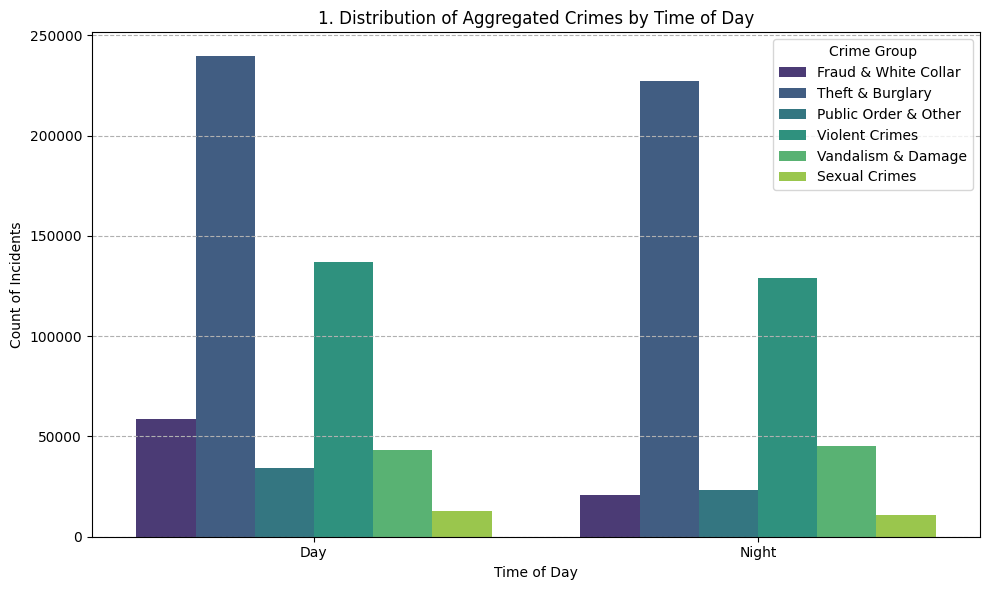

In [30]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df,
    x='Is_Night_Time',
    hue='Crm Cd Desc',
    palette='viridis'
)
plt.title('1. Distribution of Aggregated Crimes by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Count of Incidents')
plt.xticks([0, 1], ['Day', 'Night'])
plt.legend(title='Crime Group')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

C:\Users\muhan\AppData\Local\Temp\ipykernel_11016\667250914.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


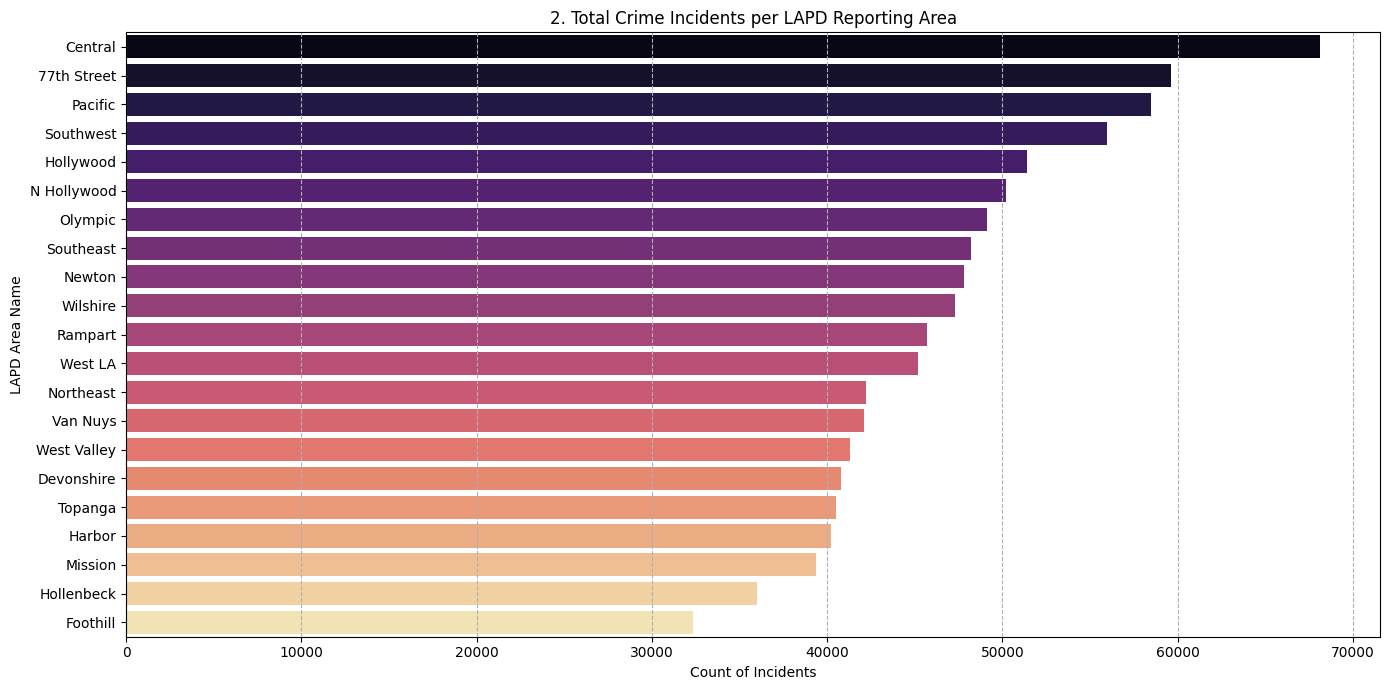

In [31]:
plt.figure(figsize=(14, 7))
sns.countplot(
    data=df,
    y='AREA NAME',
    order=df['AREA NAME'].value_counts().index,
    palette='magma'
)
plt.title('2. Total Crime Incidents per LAPD Reporting Area')
plt.xlabel('Count of Incidents')
plt.ylabel('LAPD Area Name')
plt.grid(axis='x', linestyle='--')
plt.tight_layout()
plt.show()

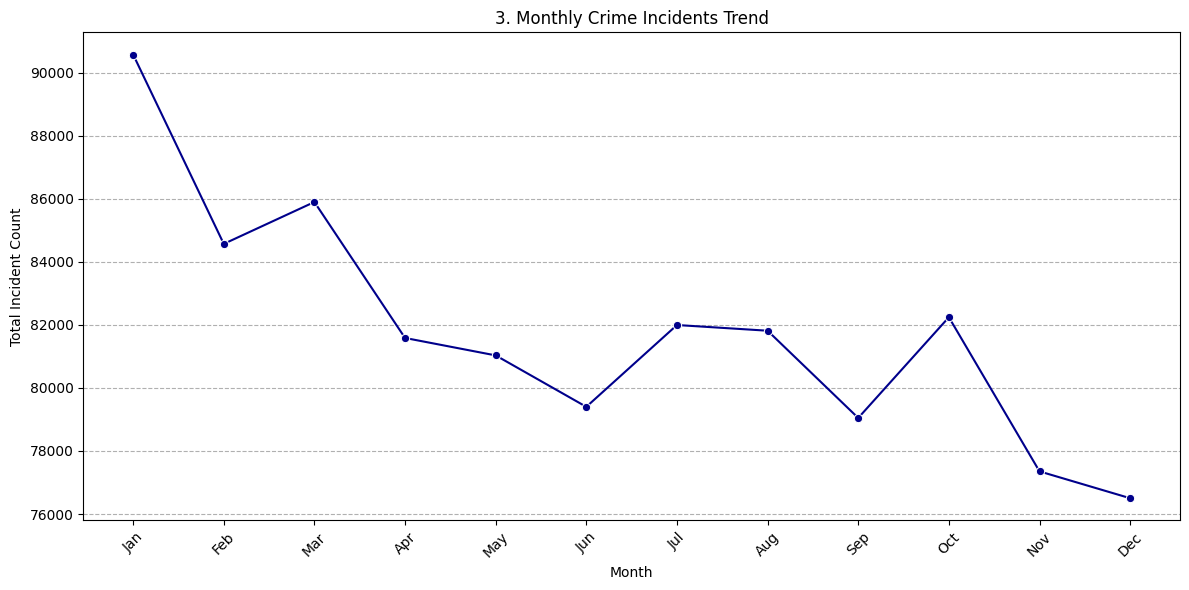

In [32]:
monthly_crime_counts = df.groupby('Month').size().reset_index(name='Count')

month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=monthly_crime_counts,
    x='Month',
    y='Count',
    marker='o',
    color='darkblue'
)
plt.title('3. Monthly Crime Incidents Trend')
plt.xlabel('Month')
plt.ylabel('Total Incident Count')
plt.xticks(ticks=monthly_crime_counts['Month'], labels=month_labels, rotation=45) 
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

C:\Users\muhan\AppData\Local\Temp\ipykernel_11016\1312094223.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


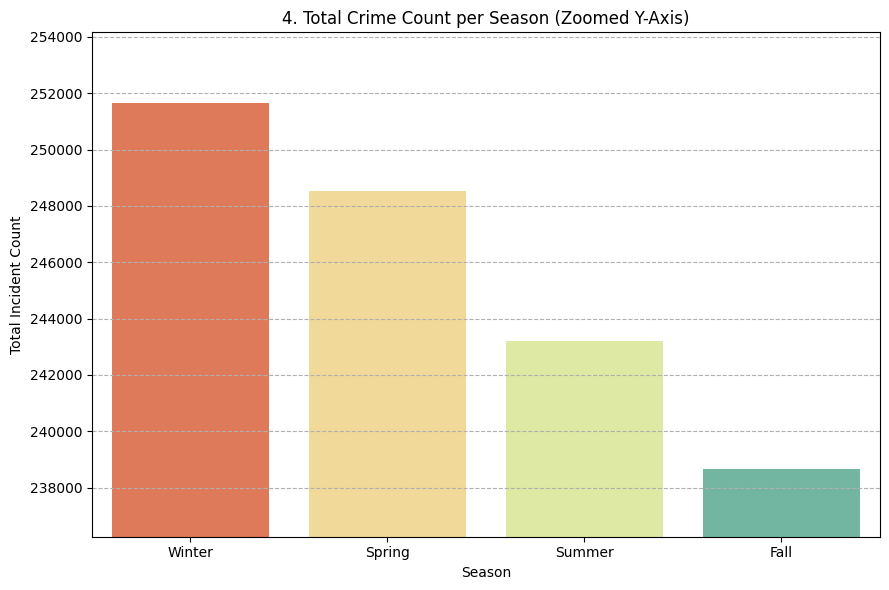

In [33]:
season_counts = df['Season'].value_counts()
min_crime_count = season_counts.min()

y_start_limit = min_crime_count * 0.99 

season_order_by_count = season_counts.sort_values(ascending=True).index

plt.figure(figsize=(9, 6))
sns.countplot(
    data=df,
    x='Season',
    order=['Winter', 'Spring', 'Summer', 'Fall'],
    palette='Spectral'
)

plt.ylim(y_start_limit, season_counts.max() * 1.01) 

plt.title('4. Total Crime Count per Season (Zoomed Y-Axis)')
plt.xlabel('Season')
plt.ylabel('Total Incident Count')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

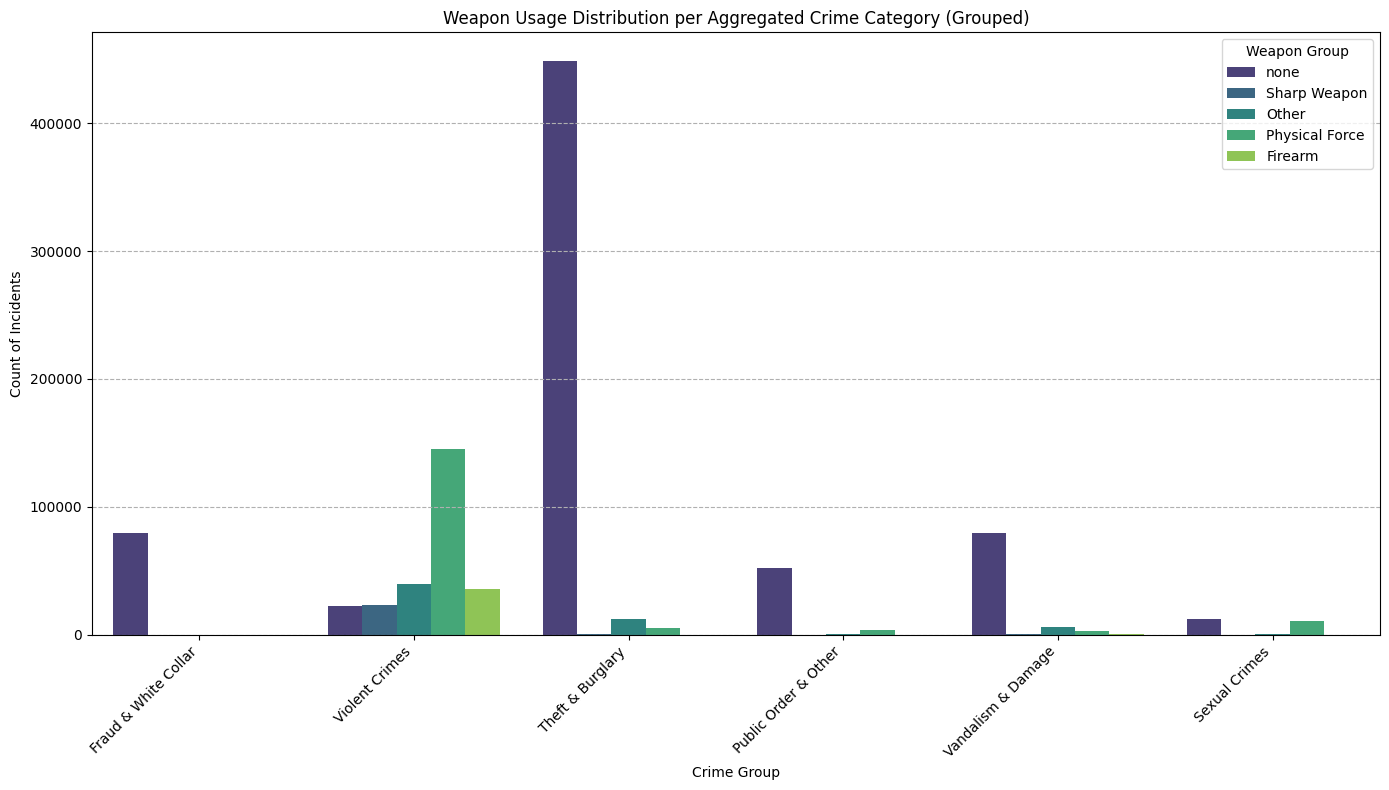

In [34]:
plt.figure(figsize=(14, 8))
sns.countplot(
    data=df,
    x='Crm Cd Desc',
    hue='Weapon Desc',
    palette='viridis'
)
plt.title('Weapon Usage Distribution per Aggregated Crime Category (Grouped)')
plt.xlabel('Crime Group')
plt.ylabel('Count of Incidents')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Weapon Group', loc='upper right')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

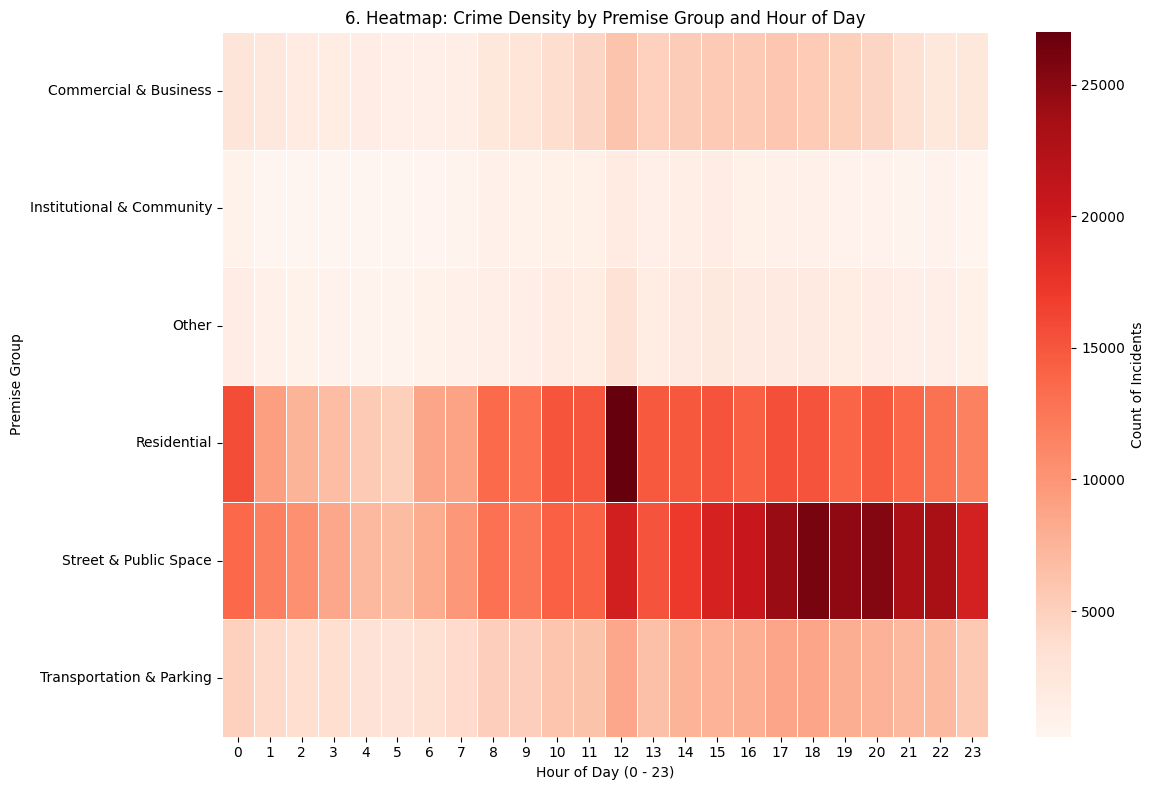

In [35]:
crime_time_location = df.groupby(['Premis Desc', 'Hour']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 8))
sns.heatmap(
    crime_time_location,
    cmap='Reds',
    linewidths=0.5,
    cbar_kws={'label': 'Count of Incidents'},
)
plt.title('6. Heatmap: Crime Density by Premise Group and Hour of Day')
plt.xlabel('Hour of Day (0 - 23)')
plt.ylabel('Premise Group')
plt.tight_layout()
plt.show()

Heatmap for high density

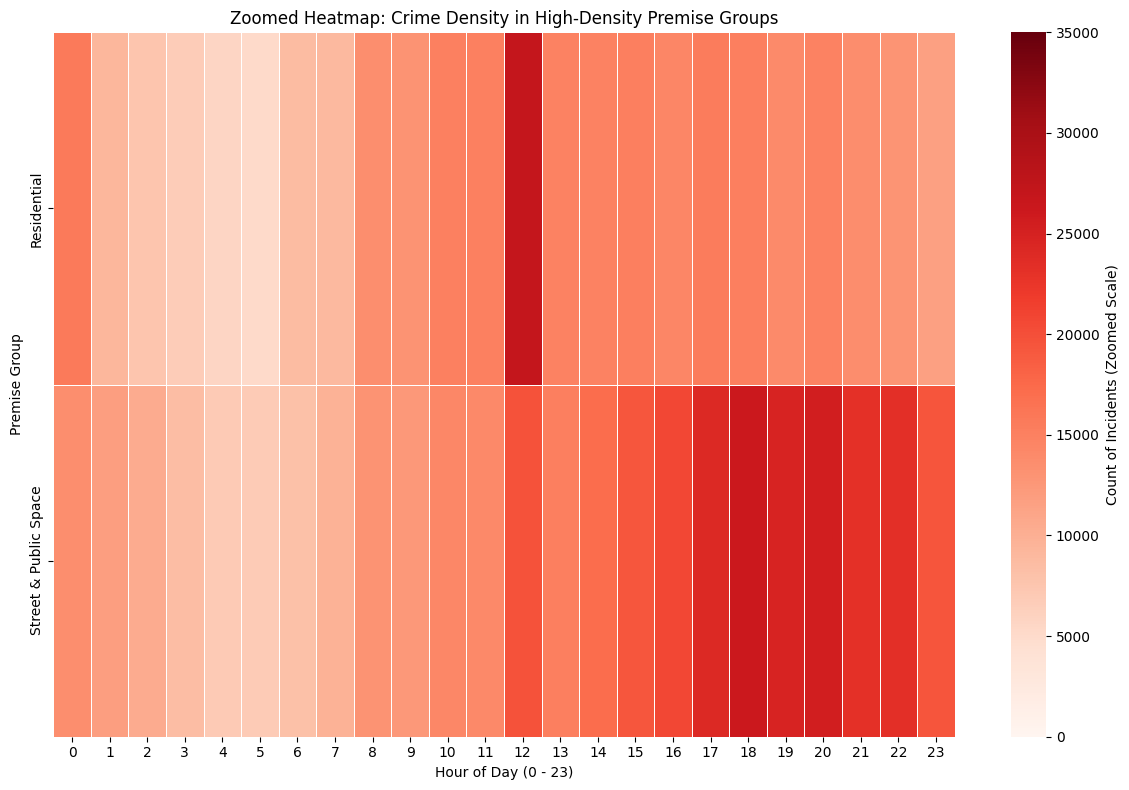

In [36]:
High_density_groups = ['Residential', 'Street & Public Space']
df_High_density = df[df['Premis Desc'].isin(High_density_groups)]

High_density_matrix = df_High_density.groupby(['Premis Desc', 'Hour']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 8))
sns.heatmap(
    High_density_matrix,
    cmap='Reds',
    linewidths=0.5,
    vmin=0, 
    vmax=35000,
    cbar_kws={'label': 'Count of Incidents (Zoomed Scale)'},
)
plt.title('Zoomed Heatmap: Crime Density in High-Density Premise Groups')
plt.xlabel('Hour of Day (0 - 23)')
plt.ylabel('Premise Group')
plt.tight_layout()
plt.show()

Heatmap for low density

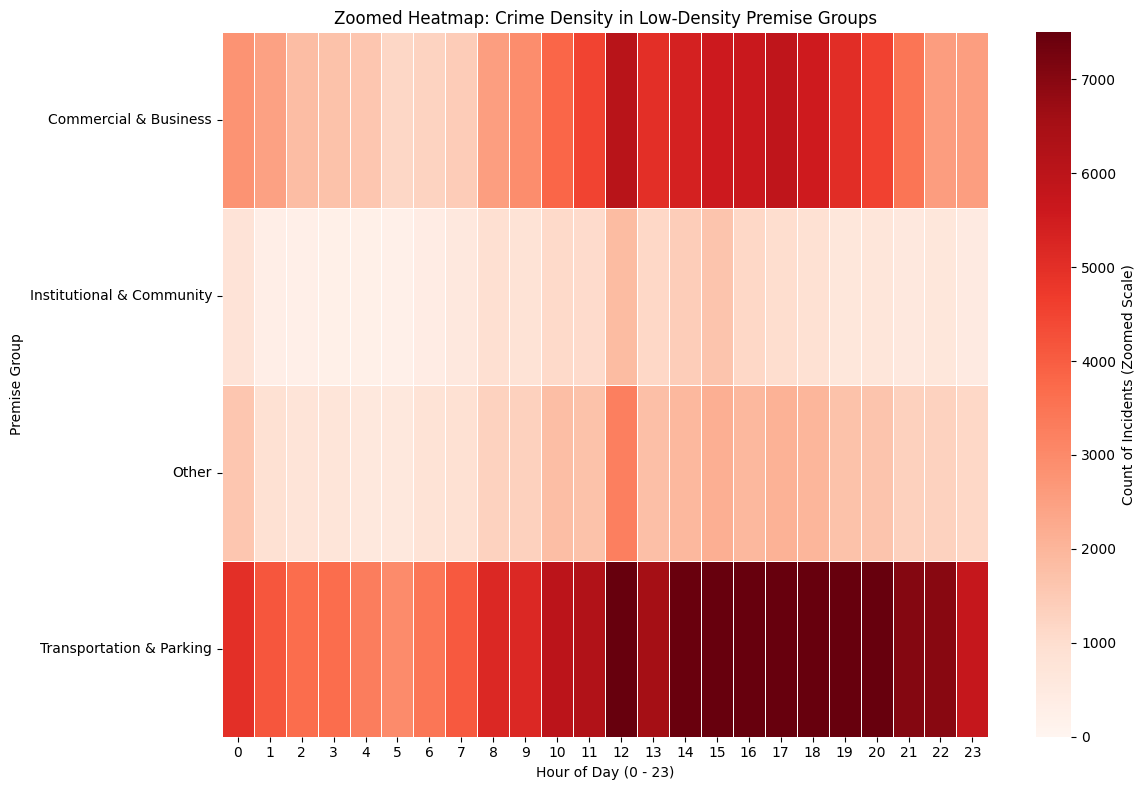

In [37]:
low_density_groups = ['Commercial & Business', 'Institutional & Community', 'Transportation & Parking', 'Other']
df_low_density = df[df['Premis Desc'].isin(low_density_groups)]

low_density_matrix = df_low_density.groupby(['Premis Desc', 'Hour']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 8))
sns.heatmap(
    low_density_matrix,
    cmap='Reds',
    linewidths=0.5,
    vmin=0, 
    vmax=7500,
    cbar_kws={'label': 'Count of Incidents (Zoomed Scale)'},
)
plt.title('Zoomed Heatmap: Crime Density in Low-Density Premise Groups')
plt.xlabel('Hour of Day (0 - 23)')
plt.ylabel('Premise Group')
plt.tight_layout()
plt.show()

In [38]:
df = df.drop(columns=['DATE OCC', 'Month', 'Hour'])

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 982018 entries, 0 to 1004990
Data columns (total 18 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   AREA NAME      982018 non-null  object        
 1   Part 1-2       982018 non-null  int64         
 2   Crm Cd Desc    982018 non-null  object        
 3   Premis Desc    982018 non-null  object        
 4   Weapon Desc    982018 non-null  object        
 5   LAT            982018 non-null  float64       
 6   LON            982018 non-null  float64       
 7   Is_Night_Time  982018 non-null  int64         
 8   Hour_sin       982018 non-null  float64       
 9   Hour_cos       982018 non-null  float64       
 10  Date           982018 non-null  datetime64[ns]
 11  DayOfWeek_sin  982018 non-null  float64       
 12  DayOfWeek_cos  982018 non-null  float64       
 13  Month_sin      982018 non-null  float64       
 14  Month_cos      982018 non-null  float64       
 15  DayO

In [40]:
df.head(5)

,AREA NAME,Part 1-2,Crm Cd Desc,Premis Desc,Weapon Desc,LAT,LON,Is_Night_Time,Hour_sin,Hour_cos,Date,DayOfWeek_sin,DayOfWeek_cos,Month_sin,Month_cos,DayOfYear_sin,DayOfYear_cos,Season
0,N Hollywood,2,Fraud & White Collar,Residential,none,34.2124,-118.4092,0,8.660254e-01,-5.000000e-01,2020-11-07,-0.974928,-0.222521,-5.000000e-01,8.660254e-01,-0.793190,0.608975,Fall
1,N Hollywood,1,Violent Crimes,Street & Public Space,Sharp Weapon,34.1993,-118.4203,1,-1.000000e+00,-1.836970e-16,2020-10-18,-0.781831,0.623490,-8.660254e-01,5.000000e-01,-0.952114,0.305743,Fall
2,Van Nuys,2,Fraud & White Collar,Residential,none,34.1847,-118.4509,0,1.224647e-16,-1.000000e+00,2020-10-30,-0.433884,-0.900969,-8.660254e-01,5.000000e-01,-0.869233,0.494403,Fall
3,Wilshire,1,Theft & Burglary,Street & Public Space,none,34.0339,-118.3747,0,-2.588190e-01,-9.659258e-01,2020-12-24,0.433884,-0.900969,-2.449294e-16,1.000000e+00,-0.107308,0.994226,Winter
4,Pacific,1,Theft & Burglary,Street & Public Space,none,33.9813,-118.4350,1,-1.000000e+00,-1.836970e-16,2020-09-29,0.781831,0.623490,-1.000000e+00,-1.836970e-16,-0.999870,-0.016127,Fall


The last thing left is the feature engineering for LAT & LON

In [41]:
min_lat = df['LAT'].min()
max_lat = df['LAT'].max()
min_lon = df['LON'].min()
max_lon = df['LON'].max()

print(f"Latitude Range: {min_lat} to {max_lat}")
print(f"Longitude Range: {min_lon} to {max_lon}")

Latitude Range: 0.0 to 34.3343
Longitude Range: -118.6676 to 0.0


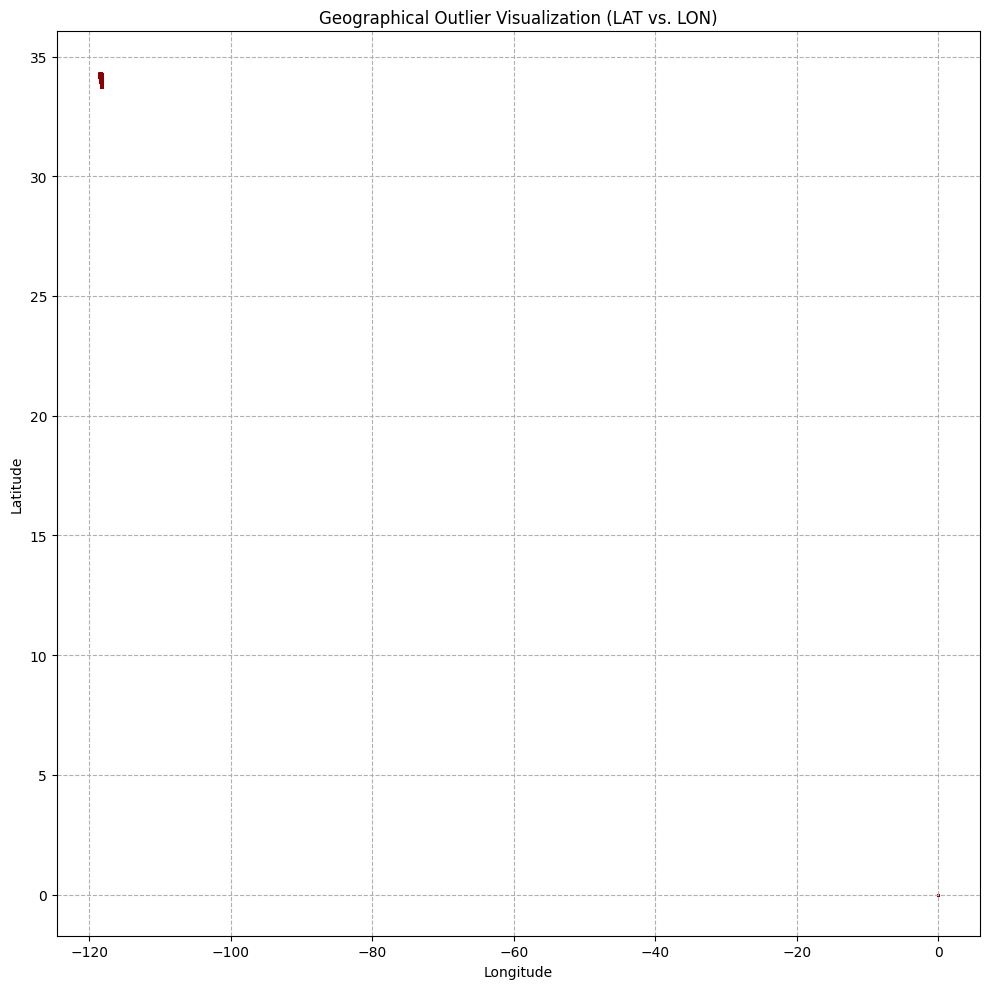

In [42]:
plt.figure(figsize=(10, 10))

sns.scatterplot(
    data=df, 
    x='LON', 
    y='LAT', 
    alpha=0.01,  
    s=5,         
    color='darkred'
)

plt.title('Geographical Outlier Visualization (LAT vs. LON)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

In [43]:
initial_rows = len(df)

df = df[
    (df['LAT'] != 0.0) & 
    (df['LON'] != 0.0)
]

rows_dropped = initial_rows - len(df)

print(f"Number of rows dropped: {rows_dropped}")

Number of rows dropped: 2188


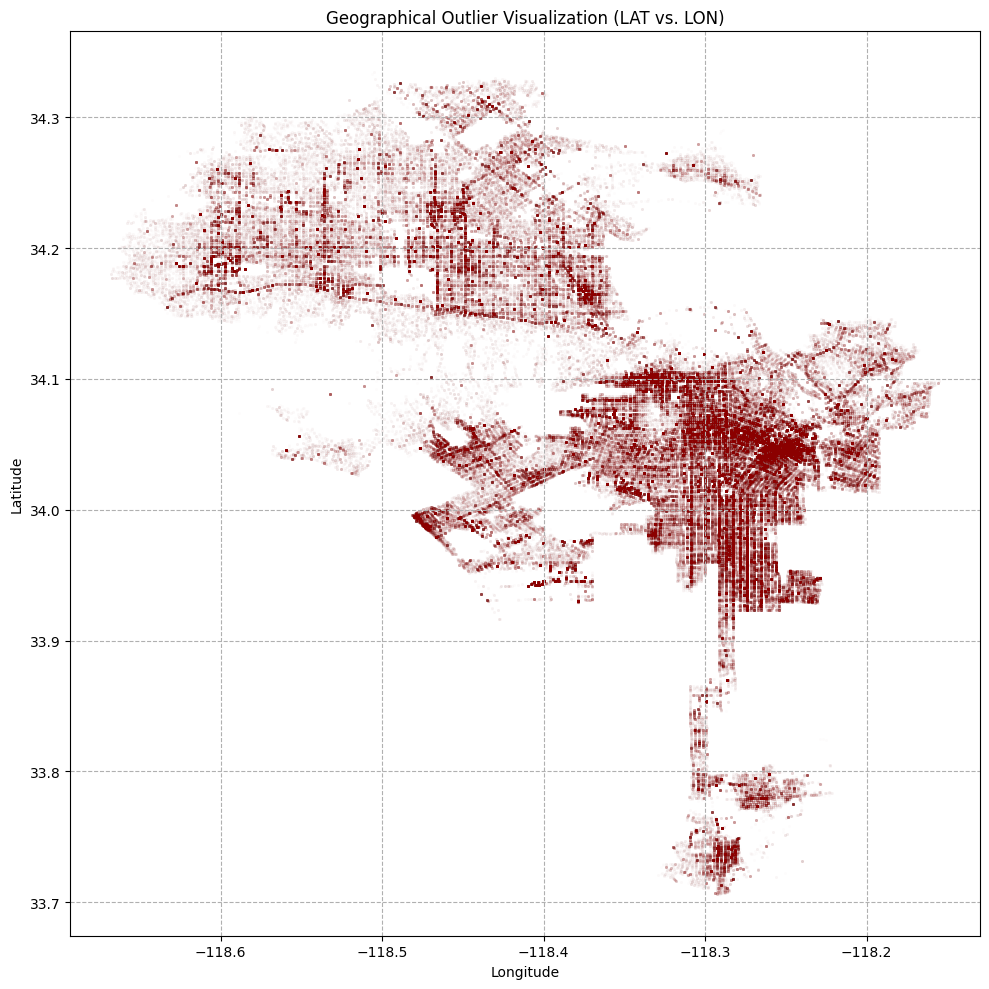

In [44]:
plt.figure(figsize=(10, 10))

sns.scatterplot(
    data=df, 
    x='LON', 
    y='LAT', 
    alpha=0.01,
    s=5, 
    color='darkred'
)

plt.title('Geographical Outlier Visualization (LAT vs. LON)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

In [45]:
min_lat = df['LAT'].min()
max_lat = df['LAT'].max()
min_lon = df['LON'].min()
max_lon = df['LON'].max()

print(f"Latitude Range: {min_lat} to {max_lat}")
print(f"Longitude Range: {min_lon} to {max_lon}")

lat_range = max_lat - min_lat
lon_range = max_lon - min_lon
print(f"Latitude Range Size: {lat_range}")
print(f"Longitude Range Size: {lon_range}")

Latitude Range: 33.7059 to 34.3343
Longitude Range: -118.6676 to -118.1554
Latitude Range Size: 0.6283999999999992
Longitude Range Size: 0.5121999999999929


we use GRID HEIGHT = 70, GRID_WIDTH = 47 to make the grid size 1 square kilometer.

In [46]:
GRID_HEIGHT = 70
GRID_WIDTH = 47

lat_bin_size = lat_range / GRID_HEIGHT
lon_bin_size = lon_range / GRID_WIDTH

def assign_to_grid(row):

    lon_offset = row['LON'] - min_lon
    lat_offset = row['LAT'] - min_lat

    grid_col = int(lon_offset / lon_bin_size)

    grid_row = int(lat_offset / lat_bin_size)

    grid_col = min(grid_col, GRID_WIDTH - 1)
    grid_row = min(grid_row, GRID_HEIGHT - 1)

    return grid_row, grid_col

df[['Grid_Row', 'Grid_Col']] = df.apply(assign_to_grid, axis=1, result_type='expand')

In [47]:
df['Is_Total'] = 1
NUM_CHANNELS_1ch = 1
daily_grid_aggregation_1ch = df.groupby(['Date', 'Grid_Row', 'Grid_Col']).agg(
    C1_Total=('Is_Total', 'sum') 
).reset_index()

unique_dates_1ch = daily_grid_aggregation_1ch['Date'].unique()
num_days_1ch = len(unique_dates_1ch)

spatial_tensor_1ch = np.zeros(
    (num_days_1ch, GRID_HEIGHT, GRID_WIDTH, NUM_CHANNELS_1ch), 
    dtype=np.float32
)

for t, date in enumerate(unique_dates_1ch):
    daily_data = daily_grid_aggregation_1ch[daily_grid_aggregation_1ch['Date'] == date]
    
    for _, row in daily_data.iterrows():
        r = int(row['Grid_Row'])
        c = int(row['Grid_Col'])
        
        spatial_tensor_1ch[t, r, c, 0] = row['C1_Total']

df.drop(columns=['Is_Total', 'Date','LAT', 'LON'], inplace=True)
print(f"spatial_tensor_1ch Shape: {spatial_tensor_1ch.shape}")

spatial_tensor_1ch Shape: (1879, 70, 47, 1)


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 979830 entries, 0 to 1004990
Data columns (total 17 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   AREA NAME      979830 non-null  object 
 1   Part 1-2       979830 non-null  int64  
 2   Crm Cd Desc    979830 non-null  object 
 3   Premis Desc    979830 non-null  object 
 4   Weapon Desc    979830 non-null  object 
 5   Is_Night_Time  979830 non-null  int64  
 6   Hour_sin       979830 non-null  float64
 7   Hour_cos       979830 non-null  float64
 8   DayOfWeek_sin  979830 non-null  float64
 9   DayOfWeek_cos  979830 non-null  float64
 10  Month_sin      979830 non-null  float64
 11  Month_cos      979830 non-null  float64
 12  DayOfYear_sin  979830 non-null  float64
 13  DayOfYear_cos  979830 non-null  float64
 14  Season         979830 non-null  object 
 15  Grid_Row       979830 non-null  int64  
 16  Grid_Col       979830 non-null  int64  
dtypes: float64(8), int64(4), object(5

In [49]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))

original_shape = spatial_tensor_1ch.shape
data_to_scale = spatial_tensor_1ch.reshape(-1, original_shape[-1]) 

scaled_data = scaler.fit_transform(data_to_scale)

spatial_tensor_scaled = scaled_data.reshape(original_shape)

spatial_tensor_1ch = spatial_tensor_scaled

In [50]:
OHE_COLUMNS = [
    'AREA NAME', 
    'Part 1-2', 
    'Crm Cd Desc', 
    'Premis Desc', 
    'Weapon Desc', 
    'Season'
]

df['Part 1-2'] = df['Part 1-2'].astype(str)

df_dummies = pd.get_dummies(df[OHE_COLUMNS], prefix=OHE_COLUMNS)

df = pd.concat([df, df_dummies], axis=1)

df.drop(columns=OHE_COLUMNS, inplace=True, errors='ignore')

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 979830 entries, 0 to 1004990
Data columns (total 55 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   Is_Night_Time                          979830 non-null  int64  
 1   Hour_sin                               979830 non-null  float64
 2   Hour_cos                               979830 non-null  float64
 3   DayOfWeek_sin                          979830 non-null  float64
 4   DayOfWeek_cos                          979830 non-null  float64
 5   Month_sin                              979830 non-null  float64
 6   Month_cos                              979830 non-null  float64
 7   DayOfYear_sin                          979830 non-null  float64
 8   DayOfYear_cos                          979830 non-null  float64
 9   Grid_Row                               979830 non-null  int64  
 10  Grid_Col                               979830 non-null  int6

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

SEQUENCE_LENGTH = 7
PREDICTION_STEPS = 1

def create_sequences(data, seq_len, pred_steps):
    X, y = [], []

    for i in range(len(data) - seq_len - pred_steps + 1):

        X.append(data[i:i + seq_len])

        y.append(data[i + seq_len:i + seq_len + pred_steps])
    return np.array(X), np.array(y)


X_1ch, y_1ch = create_sequences(spatial_tensor_1ch, SEQUENCE_LENGTH, PREDICTION_STEPS)

test_size = 0.2
RANDOM_SEED = 2

X_train_1ch, X_test_1ch, y_train_1ch, y_test_1ch = train_test_split(
    X_1ch, y_1ch, test_size=test_size, shuffle=False, random_state=RANDOM_SEED
)

print("\n--- Sequence Creation and Split Complete (Single Channel) ---")
print(f"Total Samples (N): {X_1ch.shape[0]}")
print(f"Training Input X_train Shape: {X_train_1ch.shape}")
print(f"Testing Input X_test Shape:   {X_test_1ch.shape}")
print(f"Training Output y_train Shape: {y_train_1ch.shape}")
print(f"Testing Output y_test Shape:   {y_test_1ch.shape}")


--- Sequence Creation and Split Complete (Single Channel) ---
Total Samples (N): 1872
Training Input X_train Shape: (1497, 7, 70, 47, 1)
Testing Input X_test Shape:   (375, 7, 70, 47, 1)
Training Output y_train Shape: (1497, 1, 70, 47, 1)
Testing Output y_test Shape:   (375, 1, 70, 47, 1)


In [52]:
CONTEXT_FEATURES = [
    'Is_Night_Time', 'Hour_sin', 'Hour_cos', 'DayOfWeek_sin', 'DayOfWeek_cos', 
    'Month_sin', 'Month_cos', 'DayOfYear_sin', 'DayOfYear_cos', 
    'AREA NAME_77th Street', 'AREA NAME_Central', 'AREA NAME_Devonshire', 
    'AREA NAME_Foothill', 'AREA NAME_Harbor', 'AREA NAME_Hollenbeck', 
    'AREA NAME_Hollywood', 'AREA NAME_Mission', 'AREA NAME_N Hollywood', 
    'AREA NAME_Newton', 'AREA NAME_Northeast', 'AREA NAME_Olympic', 
    'AREA NAME_Pacific', 'AREA NAME_Rampart', 'AREA NAME_Southeast', 
    'AREA NAME_Southwest', 'AREA NAME_Topanga', 'AREA NAME_Van Nuys', 
    'AREA NAME_West LA', 'AREA NAME_West Valley', 'AREA NAME_Wilshire', 
    'Part 1-2_1', 'Part 1-2_2', 'Crm Cd Desc_Fraud & White Collar', 
    'Crm Cd Desc_Public Order & Other', 'Crm Cd Desc_Sexual Crimes', 
    'Crm Cd Desc_Theft & Burglary', 'Crm Cd Desc_Vandalism & Damage', 
    'Crm Cd Desc_Violent Crimes', 'Premis Desc_Commercial & Business', 
    'Premis Desc_Institutional & Community', 'Premis Desc_Other', 
    'Premis Desc_Residential', 'Premis Desc_Street & Public Space', 
    'Premis Desc_Transportation & Parking', 'Weapon Desc_Firearm', 
    'Weapon Desc_Other', 'Weapon Desc_Physical Force', 'Weapon Desc_Sharp Weapon', 
    'Weapon Desc_none', 'Season_Fall', 'Season_Spring', 'Season_Summer', 
    'Season_Winter'
]

X_context = df[CONTEXT_FEATURES].values
X_context = X_context.astype(np.float32) 
CONTEXT_DIM = X_context.shape[1]

N_samples = X_1ch.shape[0] 
X_context_seq = X_context[:N_samples] 

X_context_train, X_context_test, _, _ = train_test_split(
    X_context_seq, y_1ch, test_size=test_size, shuffle=False, random_state=RANDOM_SEED
)

X_context_train_reshaped = np.repeat(X_context_train[:, np.newaxis, :], SEQUENCE_LENGTH, axis=1)
X_context_test_reshaped = np.repeat(X_context_test[:, np.newaxis, :], SEQUENCE_LENGTH, axis=1)

y_train_1ch_flat = np.squeeze(y_train_1ch, axis=1)
y_test_1ch_flat = np.squeeze(y_test_1ch, axis=1)

print(f"Final Context Features (Train) Shape: {X_context_train_reshaped.shape}")
print(f"Final Output (Y) Shape: {y_train_1ch_flat.shape}")

Final Context Features (Train) Shape: (1497, 7, 53)
Final Output (Y) Shape: (1497, 70, 47, 1)


In [53]:
SEQUENCE_LENGTH = 7
HEIGHT = 70
WIDTH = 47          
CHANNELS = 1
RANDOM_SEED = 2 
test_size = 0.2

In [54]:
from tensorflow import keras
from keras import layers
import tensorflow as tf


input_spatial = keras.Input(shape=(SEQUENCE_LENGTH, HEIGHT, WIDTH, CHANNELS), name='spatial_input')

convlstm_out = layers.ConvLSTM2D(
    filters=64, kernel_size=(3, 3), padding="same", return_sequences=True, activation='relu'
)(input_spatial)

convlstm_out = layers.BatchNormalization()(convlstm_out)

convlstm_out = layers.ConvLSTM2D(
    filters=32, kernel_size=(3, 3), padding="same", return_sequences=False, activation='relu'
)(convlstm_out)
flatten_spatial = layers.Flatten()(convlstm_out)



input_context = keras.Input(shape=(SEQUENCE_LENGTH, CONTEXT_DIM), name='context_input')

avg_context = layers.GlobalAveragePooling1D()(input_context) 

dense_context = layers.Dense(32, activation='relu')(avg_context)
dense_context = layers.Dropout(0.2)(dense_context)



combined = layers.concatenate([flatten_spatial, dense_context])

output_map = layers.Dense(HEIGHT * WIDTH * CHANNELS, activation='relu')(combined)
final_output = layers.Reshape((HEIGHT, WIDTH, CHANNELS), name='final_output')(output_map)

model = keras.Model(inputs=[input_spatial, input_context], outputs=final_output)

model.compile(
    loss='mse',
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    metrics=['mae'] 
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ spatial_input       │ (None, 7, 70, 47, │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm2d         │ (None, 7, 70, 47, │    150,016 │ spatial_input[0]… │
│ (ConvLSTM2D)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ context_input       │ (None, 7, 53)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 7, 70, 47, │        256 │ conv_lstm2d[0][0] │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 53)        │          0 │ context_input[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm2d_1       │ (None, 70, 47,    │    110,720 │ batch_normalizat… │
│ (ConvLSTM2D)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      1,728 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 105280)    │          0 │ conv_lstm2d_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 105312)    │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 3290)      │ 346,479,7… │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ final_output        │ (None, 70, 47, 1) │          0 │ dense_1[0][0]     │
│ (Reshape)           │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 346,742,490 (1.29 GB)

 Trainable params: 346,742,362 (1.29 GB)

 Non-trainable params: 128 (512.00 B)

In [55]:
history = model.fit(
    {'spatial_input': X_train_1ch, 'context_input': X_context_train_reshaped},
    y_train_1ch_flat,
    batch_size=32,
    epochs=15,
    validation_split=0.1,
    verbose=1
)

Epoch 1/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 141s 3s/step - loss: 6.7832e-05 - mae: 0.0027 - val_loss: 7.7354e-05 - val_mae: 0.0026
Epoch 2/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 135s 3s/step - loss: 5.6852e-05 - mae: 0.0025 - val_loss: 8.0181e-05 - val_mae: 0.0026
Epoch 3/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 134s 3s/step - loss: 5.5370e-05 - mae: 0.0025 - val_loss: 7.9748e-05 - val_mae: 0.0027
Epoch 4/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 134s 3s/step - loss: 5.4561e-05 - mae: 0.0025 - val_loss: 8.2982e-05 - val_mae: 0.0027
Epoch 5/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 133s 3s/step - loss: 5.3882e-05 - mae: 0.0025 - val_loss: 8.2331e-05 - val_mae: 0.0027
Epoch 6/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 134s 3s/step - loss: 5.3087e-05 - mae: 0.0025 - val_loss: 8.3285e-05 - val_mae: 0.0027
Epoch 7/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 134s 3s/step - loss: 5.2278e-05 - mae: 0.0025 - val_loss: 8.2244e-05 - val_mae: 0.0027
Epoch 8/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 134s 3s/step - loss: 5.1439e-05 - mae: 0.0024 - val_loss: 8.1196e-05 - val_mae: 0.0027


In [56]:
test_results = model.evaluate(
    {'spatial_input': X_test_1ch, 'context_input': X_context_test_reshaped},
    y_test_1ch_flat,
    verbose=1
)

predictions = model.predict(
    {'spatial_input': X_test_1ch[:50], 'context_input': X_context_test_reshaped[:50]}
)

print("-" * 50)
print("Final Evaluation on Test Set:")
print(f"Test Loss (MSE): {test_results[0]:.4f}")
print(f"Test MAE (Mean Absolute Error): {test_results[1]:.4f}")
print("-" * 50)
print(f"Predictions Shape (5 Samples): {predictions.shape}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 580ms/step - loss: 3.7246e-05 - mae: 0.0020
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 506ms/step
--------------------------------------------------
Final Evaluation on Test Set:
Test Loss (MSE): 0.0000
Test MAE (Mean Absolute Error): 0.0020
--------------------------------------------------
Predictions Shape (5 Samples): (50, 70, 47, 1)


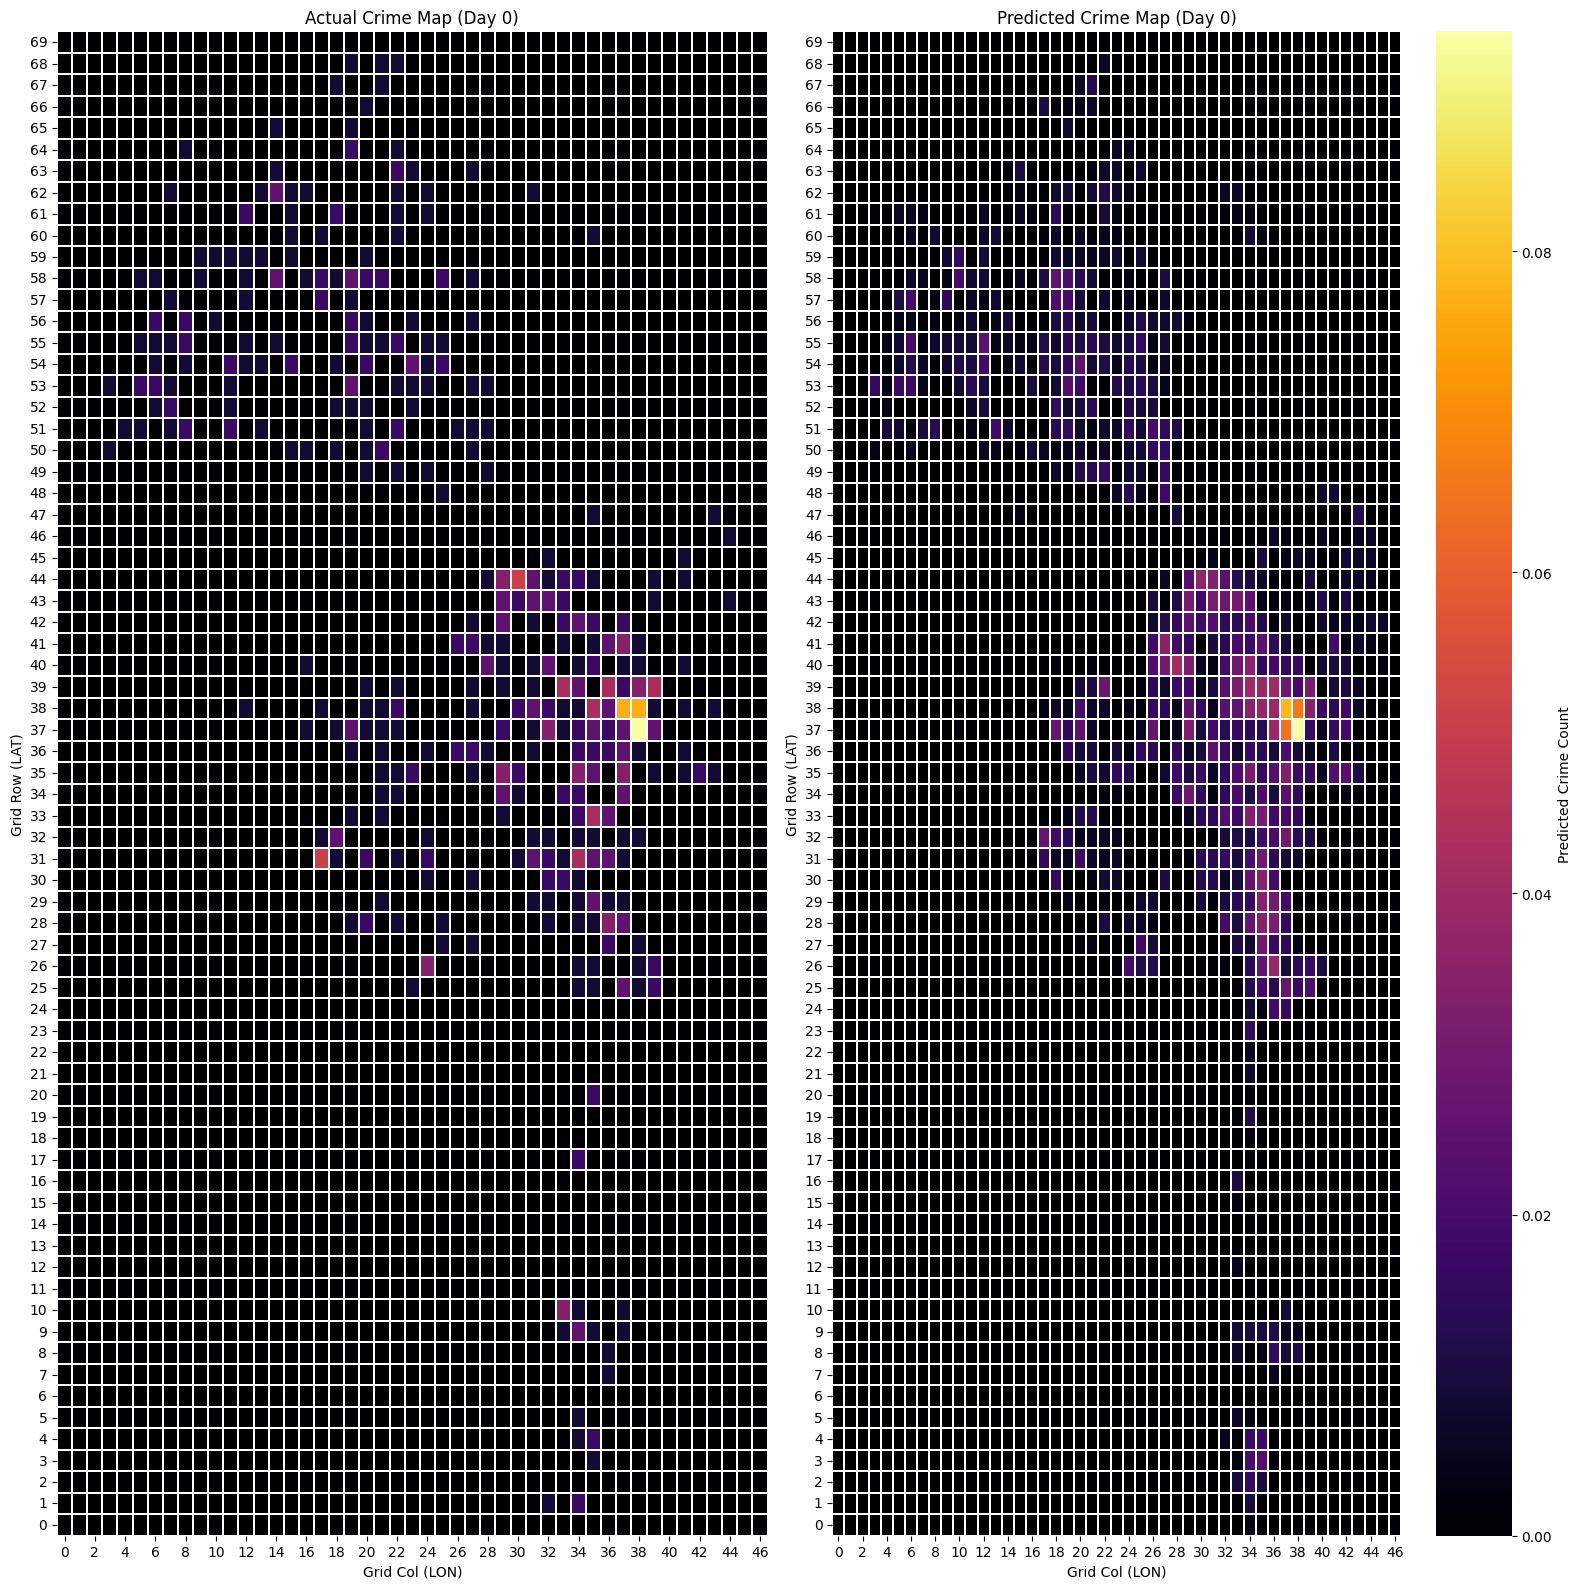

In [57]:
day_index = 0

actual_map = y_test_1ch_flat[day_index, :, :, 0] 

predicted_map = predictions[day_index, :, :, 0]

plt.figure(figsize=(16, 16))

plt.subplot(1, 2, 1)
sns.heatmap(actual_map, cmap='inferno', cbar=False, linewidths=0.01)
plt.title(f'Actual Crime Map (Day {day_index})')
plt.xlabel('Grid Col (LON)')
plt.ylabel('Grid Row (LAT)')
plt.gca().invert_yaxis()


plt.subplot(1, 2, 2)
sns.heatmap(predicted_map, cmap='inferno', cbar_kws={'label': 'Predicted Crime Count'}, linewidths=0.01)
plt.title(f'Predicted Crime Map (Day {day_index})')
plt.xlabel('Grid Col (LON)')
plt.ylabel('Grid Row (LAT)')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

K_PERCENT = 0.10

In [58]:
Y_pred_raw = model.predict({
    'spatial_input': X_test_1ch, 
    'context_input': X_context_test_reshaped
})

Y_actual_flat_scaled = y_test_1ch_flat[:, :, :, 0].flatten().reshape(-1, 1)
Y_pred_flat_scaled = Y_pred_raw[:, :, :, 0].flatten().reshape(-1, 1)

Y_actual_counts = scaler.inverse_transform(Y_actual_flat_scaled).flatten()
Y_pred_counts = scaler.inverse_transform(Y_pred_flat_scaled).flatten()

y_true = (Y_actual_counts >= 1.0).astype(int)

N_CELLS_TOTAL = Y_actual_counts.shape[0]
K_PERCENT = 0.10
K_COUNT = int(N_CELLS_TOTAL * K_PERCENT)

top_k_indices = np.argsort(Y_pred_counts)[-K_COUNT:]

y_pred = np.zeros_like(Y_pred_counts, dtype=int)
y_pred[top_k_indices] = 1

print('Classification Report')


report = classification_report(
    y_true, 
    y_pred, 
    labels=[0, 1], 
    target_names=['Coolspot', 'Hotspot']
)

print(report)

12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 589ms/step
Classification Report
              precision    recall  f1-score   support

    Coolspot       0.97      0.93      0.95   1164583
     Hotspot       0.33      0.59      0.43     69167

    accuracy                           0.91   1233750
   macro avg       0.65      0.76      0.69   1233750
weighted avg       0.94      0.91      0.92   1233750



K_PERCENT = 0.15

In [59]:
Y_pred_raw = model.predict({
    'spatial_input': X_test_1ch, 
    'context_input': X_context_test_reshaped
})

Y_actual_flat_scaled = y_test_1ch_flat[:, :, :, 0].flatten().reshape(-1, 1)
Y_pred_flat_scaled = Y_pred_raw[:, :, :, 0].flatten().reshape(-1, 1)

Y_actual_counts = scaler.inverse_transform(Y_actual_flat_scaled).flatten()
Y_pred_counts = scaler.inverse_transform(Y_pred_flat_scaled).flatten()

y_true = (Y_actual_counts >= 1.0).astype(int)

N_CELLS_TOTAL = Y_actual_counts.shape[0]
K_PERCENT = 0.15
K_COUNT = int(N_CELLS_TOTAL * K_PERCENT)

top_k_indices = np.argsort(Y_pred_counts)[-K_COUNT:]

y_pred = np.zeros_like(Y_pred_counts, dtype=int)
y_pred[top_k_indices] = 1

print('Classification Report')


report = classification_report(
    y_true, 
    y_pred, 
    labels=[0, 1], 
    target_names=['Coolspot', 'Hotspot']
)

print(report)

12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 585ms/step
Classification Report
              precision    recall  f1-score   support

    Coolspot       0.98      0.89      0.93   1164583
     Hotspot       0.28      0.75      0.41     69167

    accuracy                           0.88   1233750
   macro avg       0.63      0.82      0.67   1233750
weighted avg       0.94      0.88      0.90   1233750



K_PERCENT = 0.20

In [60]:
Y_pred_raw = model.predict({
    'spatial_input': X_test_1ch, 
    'context_input': X_context_test_reshaped
})

Y_actual_flat_scaled = y_test_1ch_flat[:, :, :, 0].flatten().reshape(-1, 1)
Y_pred_flat_scaled = Y_pred_raw[:, :, :, 0].flatten().reshape(-1, 1)

Y_actual_counts = scaler.inverse_transform(Y_actual_flat_scaled).flatten()
Y_pred_counts = scaler.inverse_transform(Y_pred_flat_scaled).flatten()

y_true = (Y_actual_counts >= 1.0).astype(int)

N_CELLS_TOTAL = Y_actual_counts.shape[0]
K_PERCENT = 0.20
K_COUNT = int(N_CELLS_TOTAL * K_PERCENT)

top_k_indices = np.argsort(Y_pred_counts)[-K_COUNT:]

y_pred = np.zeros_like(Y_pred_counts, dtype=int)
y_pred[top_k_indices] = 1

print('Classification Report')


report = classification_report(
    y_true, 
    y_pred, 
    labels=[0, 1], 
    target_names=['Coolspot', 'Hotspot']
)

print(report)

12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 589ms/step
Classification Report
              precision    recall  f1-score   support

    Coolspot       0.99      0.84      0.91   1164583
     Hotspot       0.24      0.87      0.38     69167

    accuracy                           0.84   1233750
   macro avg       0.62      0.85      0.64   1233750
weighted avg       0.95      0.84      0.88   1233750



K_PERCENT = 0.25

In [61]:
Y_pred_raw = model.predict({
    'spatial_input': X_test_1ch, 
    'context_input': X_context_test_reshaped
})

Y_actual_flat_scaled = y_test_1ch_flat[:, :, :, 0].flatten().reshape(-1, 1)
Y_pred_flat_scaled = Y_pred_raw[:, :, :, 0].flatten().reshape(-1, 1)

Y_actual_counts = scaler.inverse_transform(Y_actual_flat_scaled).flatten()
Y_pred_counts = scaler.inverse_transform(Y_pred_flat_scaled).flatten()

y_true = (Y_actual_counts >= 1.0).astype(int)

N_CELLS_TOTAL = Y_actual_counts.shape[0]
K_PERCENT = 0.25
K_COUNT = int(N_CELLS_TOTAL * K_PERCENT)

top_k_indices = np.argsort(Y_pred_counts)[-K_COUNT:]

y_pred = np.zeros_like(Y_pred_counts, dtype=int)
y_pred[top_k_indices] = 1

print('Classification Report')


report = classification_report(
    y_true, 
    y_pred, 
    labels=[0, 1], 
    target_names=['Coolspot', 'Hotspot']
)

print(report)

12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 588ms/step
Classification Report
              precision    recall  f1-score   support

    Coolspot       0.99      0.79      0.88   1164583
     Hotspot       0.19      0.87      0.32     69167

    accuracy                           0.79   1233750
   macro avg       0.59      0.83      0.60   1233750
weighted avg       0.95      0.79      0.85   1233750



In [82]:
from scipy.ndimage import binary_dilation

def spatial_classification_report(model, X_test, X_context, y_test_flat, scaler, k_percent=0.15):
    y_pred_raw = model.predict({'spatial_input': X_test, 'context_input': X_context}, verbose=0)
    
    y_pred_reshaped = y_pred_raw.reshape(-1, 1)
    y_true_reshaped = y_test_flat.reshape(-1, 1)

    y_pred_real = scaler.inverse_transform(y_pred_reshaped).flatten()
    y_true_real_flat = scaler.inverse_transform(y_true_reshaped).flatten()

    BATCH_SIZE = y_pred_raw.shape[0]
    print(f"\nTotal Test Samples: {BATCH_SIZE}, Grid Size: {HEIGHT}x{WIDTH}")
    
    y_true_maps = y_true_real_flat.reshape(BATCH_SIZE, HEIGHT, WIDTH)
    y_pred_maps = y_pred_real.reshape(BATCH_SIZE, HEIGHT, WIDTH)

    N_CELLS = HEIGHT * WIDTH
    K_COUNT = int(N_CELLS * k_percent)
    
    y_pred_binary_maps = np.zeros_like(y_pred_maps, dtype=int)
    
    for i in range(BATCH_SIZE):
        flat_pred = y_pred_maps[i].flatten()
        threshold_val = np.sort(flat_pred)[-K_COUNT]
        y_pred_binary_maps[i] = (y_pred_maps[i] >= threshold_val).astype(int)

    y_true_binary_maps = (y_true_maps >= 1.0).astype(int)

    total_actual = np.sum(y_true_binary_maps)
    total_predicted = np.sum(y_pred_binary_maps)

    tp_strict = 0
    tp_relaxed_recall = 0   
    tp_relaxed_precision = 0

    structure = np.ones((3, 3)) 
    
    for i in range(BATCH_SIZE):
        actual = y_true_binary_maps[i]
        pred = y_pred_binary_maps[i]

        tp_strict += np.sum(actual * pred)

        pred_dilated = binary_dilation(pred, structure=structure).astype(int)
        tp_relaxed_recall += np.sum(actual * pred_dilated)

        actual_dilated = binary_dilation(actual, structure=structure).astype(int)
        tp_relaxed_precision += np.sum(pred * actual_dilated)

    rec_strict = tp_strict / total_actual
    prec_strict = tp_strict / total_predicted
    f1_strict = (2 * prec_strict * rec_strict) / (prec_strict + rec_strict) if (prec_strict + rec_strict) > 0 else 0

    rec_relaxed = tp_relaxed_recall / total_actual
    prec_relaxed = tp_relaxed_precision / total_predicted
    f1_relaxed = (2 * prec_relaxed * rec_relaxed) / (prec_relaxed + rec_relaxed) if (prec_relaxed + rec_relaxed) > 0 else 0

    print("\n" + "="*65)
    print(f"{'METRIC':<20} | {'STRICT (Exact)':<15} | {'SPATIAL (Neighbor)':<15}")
    print("-" * 65)
    print(f"{'Precision':<20} | {prec_strict:.4f}{'':<9} | {prec_relaxed:.4f}")
    print(f"{'Recall':<20} | {rec_strict:.4f}{'':<9} | {rec_relaxed:.4f}")
    print(f"{'F1-Score':<20} | {f1_strict:.4f}{'':<9} | {f1_relaxed:.4f}")
    print("="*65)

spatial_classification_report(
    model,
    X_test_1ch,
    X_context_test_reshaped,
    y_test_1ch_flat,
    scaler=scaler,
    k_percent=0.15
)


Total Test Samples: 375, Grid Size: 70x47

METRIC               | STRICT (Exact)  | SPATIAL (Neighbor)
-----------------------------------------------------------------
Precision            | 0.2790          | 0.7379
Recall               | 0.7457          | 0.9626
F1-Score             | 0.4061          | 0.8354


In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

def prepare_data_for_xgboost(X_spatial, X_context, y_spatial):
    num_samples, seq_len, height, width, _ = X_spatial.shape
    num_context_features = X_context.shape[-1]
    X_tabular = []
    y_tabular = []
    
    print(f"Converting data... (Samples: {num_samples})")

    lags = X_spatial.squeeze(-1).transpose(0, 2, 3, 1) 

    context_mean = X_context.mean(axis=1) 

    grid_rows = np.repeat(np.arange(height)[:, np.newaxis], width, axis=1)
    grid_cols = np.repeat(np.arange(width)[np.newaxis, :], height, axis=0)

    y_flat = y_spatial.flatten()

    lags_flat = lags.reshape(-1, seq_len)

    context_flat = np.repeat(context_mean, height * width, axis=0)

    coords_flat = np.tile(np.stack([grid_rows, grid_cols], axis=2).reshape(-1, 2), (num_samples, 1))

    X_final = np.hstack([lags_flat, coords_flat, context_flat])
    
    return X_final, y_flat

print("Preparing Training Data for XGBoost...")
X_train_xgb, y_train_xgb = prepare_data_for_xgboost(X_train_1ch, X_context_train_reshaped, y_train_1ch)

print("Preparing Testing Data for XGBoost...")
X_test_xgb, y_test_xgb = prepare_data_for_xgboost(X_test_1ch, X_context_test_reshaped, y_test_1ch)

print(f"\nFinal XGBoost Train Shape: {X_train_xgb.shape}")
print(f"Final XGBoost Test Shape:  {X_test_xgb.shape}")

Preparing Training Data for XGBoost...
Converting data... (Samples: 1497)
Preparing Testing Data for XGBoost...
Converting data... (Samples: 375)

Final XGBoost Train Shape: (4925130, 62)
Final XGBoost Test Shape:  (1233750, 62)


In [63]:
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    tree_method='hist',
    device='cuda',
    random_state=2
)

xgb_model.fit(
    X_train_xgb, 
    y_train_xgb,
    eval_set=[(X_test_xgb, y_test_xgb)],
    verbose=True
)

[0]	validation_0-rmse:0.00647


c:\Users\muhan\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:199: UserWarning: [23:22:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\muhan\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:199: UserWarning: [23:22:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


[1]	validation_0-rmse:0.00626
[2]	validation_0-rmse:0.00608
[3]	validation_0-rmse:0.00593
[4]	validation_0-rmse:0.00581
[5]	validation_0-rmse:0.00570
[6]	validation_0-rmse:0.00562
[7]	validation_0-rmse:0.00555
[8]	validation_0-rmse:0.00549
[9]	validation_0-rmse:0.00544
[10]	validation_0-rmse:0.00540
[11]	validation_0-rmse:0.00537
[12]	validation_0-rmse:0.00534
[13]	validation_0-rmse:0.00532
[14]	validation_0-rmse:0.00530
[15]	validation_0-rmse:0.00529
[16]	validation_0-rmse:0.00527
[17]	validation_0-rmse:0.00526
[18]	validation_0-rmse:0.00526
[19]	validation_0-rmse:0.00525
[20]	validation_0-rmse:0.00524
[21]	validation_0-rmse:0.00524
[22]	validation_0-rmse:0.00524
[23]	validation_0-rmse:0.00524
[24]	validation_0-rmse:0.00523
[25]	validation_0-rmse:0.00523
[26]	validation_0-rmse:0.00523
[27]	validation_0-rmse:0.00523
[28]	validation_0-rmse:0.00523
[29]	validation_0-rmse:0.00523
[30]	validation_0-rmse:0.00522
[31]	validation_0-rmse:0.00522
[32]	validation_0-rmse:0.00522
[33]	validation_0

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device='cuda', early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

K_PERCENT = 0.10

In [64]:
print("Making Predictions...")
y_pred_xgb_flat = xgb_model.predict(X_test_xgb)

mae_xgb = mean_absolute_error(y_test_xgb, y_pred_xgb_flat)
mse_xgb = mean_squared_error(y_test_xgb, y_pred_xgb_flat)

print("-" * 50)
print("XGBoost Performance (Scaled Data):")
print(f"MAE: {mae_xgb:.4f}")
print(f"MSE: {mse_xgb:.4f}")
print("-" * 50)

y_test_inv = scaler.inverse_transform(y_test_xgb.reshape(-1, 1)).flatten()
y_pred_inv = scaler.inverse_transform(y_pred_xgb_flat.reshape(-1, 1)).flatten()

N_CELLS = len(y_test_inv)
K_PERCENT = 0.10
K_COUNT = int(N_CELLS * K_PERCENT)

y_true_binary = (y_test_inv >= 1.0).astype(int)

top_k_indices = np.argsort(y_pred_inv)[-K_COUNT:]
y_pred_binary = np.zeros_like(y_pred_inv, dtype=int)
y_pred_binary[top_k_indices] = 1

print(classification_report(y_true_binary, y_pred_binary, target_names=['Coolspot', 'Hotspot']))

Making Predictions...
--------------------------------------------------
XGBoost Performance (Scaled Data):
MAE: 0.0018
MSE: 0.0000
--------------------------------------------------
              precision    recall  f1-score   support

    Coolspot       0.98      0.93      0.96   1164583
     Hotspot       0.37      0.67      0.48     69167

    accuracy                           0.92   1233750
   macro avg       0.68      0.80      0.72   1233750
weighted avg       0.95      0.92      0.93   1233750



K_PERCENT = 0.15

In [65]:
print("Making Predictions...")
y_pred_xgb_flat = xgb_model.predict(X_test_xgb)

mae_xgb = mean_absolute_error(y_test_xgb, y_pred_xgb_flat)
mse_xgb = mean_squared_error(y_test_xgb, y_pred_xgb_flat)

print("-" * 50)
print("XGBoost Performance (Scaled Data):")
print(f"MAE: {mae_xgb:.4f}")
print(f"MSE: {mse_xgb:.4f}")
print("-" * 50)

y_test_inv = scaler.inverse_transform(y_test_xgb.reshape(-1, 1)).flatten()
y_pred_inv = scaler.inverse_transform(y_pred_xgb_flat.reshape(-1, 1)).flatten()

N_CELLS = len(y_test_inv)
K_PERCENT = 0.15
K_COUNT = int(N_CELLS * K_PERCENT)

y_true_binary = (y_test_inv >= 1.0).astype(int)

top_k_indices = np.argsort(y_pred_inv)[-K_COUNT:]
y_pred_binary = np.zeros_like(y_pred_inv, dtype=int)
y_pred_binary[top_k_indices] = 1

print(classification_report(y_true_binary, y_pred_binary, target_names=['Coolspot', 'Hotspot']))

Making Predictions...
--------------------------------------------------
XGBoost Performance (Scaled Data):
MAE: 0.0018
MSE: 0.0000
--------------------------------------------------
              precision    recall  f1-score   support

    Coolspot       0.99      0.89      0.94   1164583
     Hotspot       0.30      0.81      0.44     69167

    accuracy                           0.88   1233750
   macro avg       0.64      0.85      0.69   1233750
weighted avg       0.95      0.88      0.91   1233750



K_PERCENT = 0.20

In [66]:
print("Making Predictions...")
y_pred_xgb_flat = xgb_model.predict(X_test_xgb)

mae_xgb = mean_absolute_error(y_test_xgb, y_pred_xgb_flat)
mse_xgb = mean_squared_error(y_test_xgb, y_pred_xgb_flat)

print("-" * 50)
print("XGBoost Performance (Scaled Data):")
print(f"MAE: {mae_xgb:.4f}")
print(f"MSE: {mse_xgb:.4f}")
print("-" * 50)

y_test_inv = scaler.inverse_transform(y_test_xgb.reshape(-1, 1)).flatten()
y_pred_inv = scaler.inverse_transform(y_pred_xgb_flat.reshape(-1, 1)).flatten()

N_CELLS = len(y_test_inv)
K_PERCENT = 0.20
K_COUNT = int(N_CELLS * K_PERCENT)

y_true_binary = (y_test_inv >= 1.0).astype(int)

top_k_indices = np.argsort(y_pred_inv)[-K_COUNT:]
y_pred_binary = np.zeros_like(y_pred_inv, dtype=int)
y_pred_binary[top_k_indices] = 1

print(classification_report(y_true_binary, y_pred_binary, target_names=['Coolspot', 'Hotspot']))

Making Predictions...
--------------------------------------------------
XGBoost Performance (Scaled Data):
MAE: 0.0018
MSE: 0.0000
--------------------------------------------------
              precision    recall  f1-score   support

    Coolspot       0.99      0.84      0.91   1164583
     Hotspot       0.25      0.88      0.38     69167

    accuracy                           0.84   1233750
   macro avg       0.62      0.86      0.65   1233750
weighted avg       0.95      0.84      0.88   1233750



K_PERCENT = 0.25

In [67]:
print("Making Predictions...")
y_pred_xgb_flat = xgb_model.predict(X_test_xgb)

mae_xgb = mean_absolute_error(y_test_xgb, y_pred_xgb_flat)
mse_xgb = mean_squared_error(y_test_xgb, y_pred_xgb_flat)

print("-" * 50)
print("XGBoost Performance (Scaled Data):")
print(f"MAE: {mae_xgb:.4f}")
print(f"MSE: {mse_xgb:.4f}")
print("-" * 50)

y_test_inv = scaler.inverse_transform(y_test_xgb.reshape(-1, 1)).flatten()
y_pred_inv = scaler.inverse_transform(y_pred_xgb_flat.reshape(-1, 1)).flatten()

N_CELLS = len(y_test_inv)
K_PERCENT = 0.25
K_COUNT = int(N_CELLS * K_PERCENT)

y_true_binary = (y_test_inv >= 1.0).astype(int)

top_k_indices = np.argsort(y_pred_inv)[-K_COUNT:]
y_pred_binary = np.zeros_like(y_pred_inv, dtype=int)
y_pred_binary[top_k_indices] = 1

print(classification_report(y_true_binary, y_pred_binary, target_names=['Coolspot', 'Hotspot']))

Making Predictions...
--------------------------------------------------
XGBoost Performance (Scaled Data):
MAE: 0.0018
MSE: 0.0000
--------------------------------------------------
              precision    recall  f1-score   support

    Coolspot       0.99      0.79      0.88   1164583
     Hotspot       0.21      0.93      0.34     69167

    accuracy                           0.80   1233750
   macro avg       0.60      0.86      0.61   1233750
weighted avg       0.95      0.80      0.85   1233750



In [ ]:
from scipy.ndimage import binary_dilation

def xgb_spatial_classification_report_global(model, X_test, y_test, scaler, height, width, k_percent=0.15):

    y_pred_flat = model.predict(X_test)

    y_pred_real = scaler.inverse_transform(y_pred_flat.reshape(-1, 1)).flatten()
    y_true_real = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

    total_cells_all_days = len(y_pred_real)
    K_GLOBAL_COUNT = int(total_cells_all_days * k_percent)
    
    global_threshold = np.sort(y_pred_real)[-K_GLOBAL_COUNT]
    
    y_pred_binary_all = (y_pred_real >= global_threshold).astype(int)

    y_true_binary_all = (y_true_real >= 1.0).astype(int)

    n_total_samples = len(y_pred_real)
    map_size = height * width
    BATCH_SIZE = n_total_samples // map_size

    y_true_binary_maps = y_true_binary_all.reshape(BATCH_SIZE, height, width)
    y_pred_binary_maps = y_pred_binary_all.reshape(BATCH_SIZE, height, width)
    
    total_actual = np.sum(y_true_binary_maps)
    total_predicted = np.sum(y_pred_binary_maps)

    tp_strict = 0
    tp_relaxed_recall = 0   
    tp_relaxed_precision = 0
    
    structure = np.ones((3, 3))
    
    for i in range(BATCH_SIZE):
        actual = y_true_binary_maps[i]
        pred = y_pred_binary_maps[i]

        tp_strict += np.sum(actual * pred)

        pred_dilated = binary_dilation(pred, structure=structure).astype(int)
        tp_relaxed_recall += np.sum(actual * pred_dilated)
        
        actual_dilated = binary_dilation(actual, structure=structure).astype(int)
        tp_relaxed_precision += np.sum(pred * actual_dilated)

    rec_strict = tp_strict / total_actual
    prec_strict = tp_strict / total_predicted
    f1_strict = (2 * prec_strict * rec_strict) / (prec_strict + rec_strict) if (prec_strict + rec_strict) > 0 else 0
    
    rec_relaxed = tp_relaxed_recall / total_actual
    prec_relaxed = tp_relaxed_precision / total_predicted
    f1_relaxed = (2 * prec_relaxed * rec_relaxed) / (prec_relaxed + rec_relaxed) if (prec_relaxed + rec_relaxed) > 0 else 0

    print("="*65)
    print(f"{'METRIC':<20} | {'STRICT (Exact)':<15} | {'SPATIAL (Neighbor)':<15}")
    print("-" * 65)
    print(f"{'Precision':<20} | {prec_strict:.4f}{'':<9} | {prec_relaxed:.4f}")
    print(f"{'Recall':<20} | {rec_strict:.4f}{'':<9} | {rec_relaxed:.4f}")
    print(f"{'F1-Score':<20} | {f1_strict:.4f}{'':<9} | {f1_relaxed:.4f}")
    print("="*65)

xgb_spatial_classification_report_global(
    xgb_model,
    X_test_xgb,
    y_test_xgb,
    scaler=scaler,
    height=GRID_HEIGHT,
    width=GRID_WIDTH,
    k_percent=0.15
)

METRIC               | STRICT (Exact)  | SPATIAL (Neighbor)
-----------------------------------------------------------------
Precision            | 0.3008          | 0.8433
Recall               | 0.8052          | 0.9701
F1-Score             | 0.4380          | 0.9023
